In [1]:
import numpy as np
from pyscf import gto, scf, cc
import jax
jax.config.update("jax_enable_x64", True)

####  test H2 monomers ####
a = 2. # bond length in a cluster
d = 10 # distance between each cluster
unit = 'b' # unit of length
na = 2 # size of a cluster (monomer)
nc = 1 # set as integer multiple of monomers
spin = 0 # spin per monomer
elmt = 'C'
unit = 'B'
basis = 'sto6g'
atoms = ''
for n in range(nc*na):
    shift = ((n - n % na) // na) * (d-a)
    atoms += f"{elmt} {n*a+shift:.5f} 0.00000 0.00000 \n"
###########################

mol = gto.M(atom=atoms,
            basis=basis,
            verbose=4,
            unit=unit,
            symmetry=0,
            charge=0,
            spin=spin,
            max_memory=40000,
            )

mf = scf.RHF(mol)
mf.kernel()

stable = False
for i in range(10):
    print(f'mf stability test {i+1}')
    if not stable:
        mo_i, _, stable,_ = mf.stability(return_status=True)
        dm = mf.make_rdm1(mo_i,mf.mo_occ)
        mf.kernel(dm0=dm)
    elif stable:
        print(f'mf energy: {mf.e_tot}, stability {stable}')
        break

mycc = cc.CCSD(mf).set_frozen()
mycc.kernel()

et = mycc.ccsd_t()
print(f"CCSD(T) Energy = {mycc.e_tot + et}")

System: uname_result(system='Linux', node='sharmagroup-rn', release='7.0.0-28-generic', version='#28~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Wed Jul  1 15:50:57 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Mon Aug 10 11:51:23 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 2
[INPUT] num. electrons = 12
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = B
[INPUT] Symbol           X                Y                Z      unit

In [2]:
from afqmc import prep_exp
from afqmc import integral
integral.prep_integral(mycc, chol_cut=1e-6)


Preparing AFQMC calculation
CCSD type input object
Calculating Cholesky integrals
Cholesky shape: (49, 8, 8) 
Finished calculating Cholesky integrals
Size of the correlation space:
Number of electrons:        [4, 4]
Number of basis functions:  8
Number of Cholesky vectors: 49


In [53]:
from functools import partial
from jax import jit, lax, random
from afqmc import cc_tools

@partial(jit, static_argnums=(0, 1))
def propagate(
    self,
    trial,
    ham_data: dict,
    prop_data: dict,
    fields: jax.Array,
    wave_data: dict,
) -> dict:
    
    overlaps00 = prop_data["overlaps"] # <G(i)|w(i)>
    # update Guide <G(i)| -> <G(i+1)|
    wave_data["slaters"], prop_data["key"] = cc_tools.get_stoccsd(
        wave_data["mo_t"], wave_data["tau"], self.n_slater, prop_data["key"])
    # <G(i+1)|w(i)>
    overlaps10 = trial.calc_overlap(prop_data["walkers"], wave_data)
    
    force_bias = trial.calc_force_bias(prop_data["walkers"], ham_data, wave_data)
    field_shifts = -jnp.sqrt(self.dt) * (1.0j * force_bias - ham_data["mf_shifts"]) # xbar
    shifted_fields = fields - field_shifts # x-xbar
    shift_term = jnp.sum(shifted_fields * ham_data["mf_shifts"], axis=1) # (x-xbar)*m
    fb_term = jnp.sum(
        fields * field_shifts - field_shifts * field_shifts / 2.0, axis=1
    ) # x*xbar - xbar^2/2

    prop_data["walkers"] = self._apply_trotprop(
        ham_data, prop_data["walkers"], shifted_fields
    ) # exp(-th1/2) exp(sqrt(t)(x-xbar)v) exp(-th1/2) |w>

    # <G(i+1)|w(i+1)>
    overlaps11 = trial.calc_overlap(prop_data["walkers"], wave_data)
    # I(x,xbar,walkers,trial) = <trial|walkers_new>/<trial|walkers_old> 
    #                                 * exp(x_g xbar_g - 1/2 xbar_g xbar_g)

    Rg = overlaps10 / overlaps00 # <G(i+1)|w(i)>/<G(i)|w(i)> -- update guide
    Rw = overlaps11 / overlaps10 # <G(i+1)|w(i+1)>/<G(i+1)|w(i)> -- update walker 

    imp_fun = jnp.exp(-jnp.sqrt(self.dt) * shift_term # from sqrt(t)(x-xbar)(v-m)
                      + fb_term # pop_control_ene_shift = estimated ground state energy
                      + self.dt * (prop_data["pop_control_ene_shift"] + ham_data["h0_prop"])
                      ) * Rw * jnp.abs(Rg)
    
    theta_g = jnp.angle(Rg)
    theta_w = jnp.angle(jnp.exp(-jnp.sqrt(self.dt) * shift_term) * Rw)
    cos_g = jnp.cos(theta_g)
    cos_w = jnp.cos(theta_w)
    # cos_g = jnp.where(cos_g < 0, 0.0, cos_g)
    cos_w = jnp.where(cos_w < 0, 0.0, cos_w)

    imp_fun_phaseless = jnp.abs(imp_fun) * cos_w
    imp_fun_phaseless = jnp.array(jnp.where(jnp.isnan(imp_fun_phaseless), 0.0, imp_fun_phaseless))
    imp_fun_phaseless = jnp.where(imp_fun_phaseless < 1.0e-3, 0.0, imp_fun_phaseless)
    imp_fun_phaseless = jnp.where(imp_fun_phaseless > 100.0, 0.0, imp_fun_phaseless)

    prop_data["weights"] = imp_fun_phaseless * prop_data["weights"]
    prop_data["weights"] = jnp.array(jnp.where(prop_data["weights"] > 100, 0.0, prop_data["weights"]))
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"] \
        - 0.1 * jnp.array(jnp.log(jnp.sum(prop_data["weights"]) / self.n_walkers) / self.dt)
    prop_data["overlaps"] = overlaps11
    prop_data["cos_w"] = cos_w
    prop_data["cos_g"] = cos_g

    return prop_data, wave_data

In [54]:
from afqmc import sampling_exp

@partial(jit, static_argnums=(0, 1, 2))
def prop_nstep(sampler, prop, wave, prop_data, ham_data, wave_data):
    """Phaseless propagation scan function over steps."""
    prop_data["key"], subkey = random.split(prop_data["key"])
    fields = random.normal(
        subkey,
        shape=(
            sampler.n_prop_steps,
            sampler.n_walkers,
            sampler.n_chol,
        ),
    )

    def scan_fn(carry, field):
        prop_data, wave_data = carry
        prop_data, wave_data = propagate(prop, wave, ham_data, prop_data, field, wave_data)
        return (prop_data, wave_data), None

    (prop_data, wave_data), _ = lax.scan(scan_fn, (prop_data, wave_data), fields)

    prop_data["n_killed_walkers"] \
        = prop_data["weights"].size - jnp.count_nonzero(prop_data["weights"])

    prop_data = prop.orthonormalize_walkers(prop_data)

    return prop_data, wave_data


@partial(jit, static_argnums=(0,1,2))
def block_sample(
    sampler,
    prop,
    wave,
    prop_data,
    ham_data,
    wave_data,
    ):
    """Block scan function. Propagation and energy calculation."""
    prop_data, wave_data = prop_nstep(sampler, prop, wave, prop_data, ham_data, wave_data)
    
    guide_olps = wave.calc_overlap(prop_data["walkers"], wave_data)
    guide_enes = wave.calc_guide_energy(prop_data["walkers"], ham_data, wave_data)

    outlier = jnp.abs(guide_enes - prop_data["e_estimate"]) > jnp.sqrt(2.0 / prop.dt) # 20 Ha for dt = 0.005
    prop_data["weights"] = jnp.where(outlier, 0.0, prop_data["weights"])

    trial_olps = wave.calc_trial_overlap(prop_data["walkers"], wave_data)
    trial_enes = wave.calc_energy(prop_data["walkers"], ham_data, wave_data)

    olp_ratio = trial_olps / guide_olps
    weighps = prop_data["weights"] * olp_ratio

    # wt, gsp_mean, gsp_err = sampling_exp.weighted_average(prop_data["weights"], guide_enes)
    wp, tsp_mean, tsp_err = sampling_exp.weighted_average(weighps, trial_enes)

    prop_data = prop.stochastic_reconfiguration_local(prop_data)
    prop_data["overlaps"] = wave.calc_overlap(prop_data["walkers"], wave_data)

    return prop_data, (wp, tsp_mean, tsp_err)

In [46]:
options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'guide': 'rstoccsd',
            'trial': 'rhf',
            't2_thresh': 1e-3,
            'n_slater': 10,
            }

import time
import numpy as np
from jax import numpy as jnp

from afqmc import config
from afqmc import prep_exp, sampling_exp

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep_exp.print_start()
config.setup_jax()

prop, wave, ham_data, wave_data, sampler, options = prep_exp.init_afqmc(options=options)

ham_data, wave_data = wave.build_intermediate(ham_data, wave_data)
ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data, init_w, init_e = prep_exp.init_prop_data(wave, wave_data, ham_data, options)
prop_data["cos_g"] = jnp.ones(options["n_walkers"], dtype=jnp.float64)
prop_data["cos_w"] = jnp.ones(options["n_walkers"], dtype=jnp.float64)
print(init_w, init_e)


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-28-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers     

In [47]:
print("\nEquilibration")
print(f"{'1/T':>5s}  {'weight':>10s}  "
      f"{'energy':>12s}  {'error':>12s}  {'Time':>10s}")
print(f"{0.:5.2f}  {init_w:10.5f}  {init_e:12.5f}  "
      f"{time.time() - init_time:10.2f}")

block_time = prop.dt * sampler.n_prop_steps
nsamples = 500

# wts_sp = np.zeros(nsamples, np.complex128)
# eng_sp = np.zeros(nsamples, np.complex128)
wps_sp = np.zeros(nsamples, np.complex128)
ent_sp = np.zeros(nsamples, np.complex128)

for n in range(nsamples):
    prop_data, (wp, tsp_mean, tsp_err) \
        = block_sample(sampler, prop, wave, prop_data, ham_data, wave_data)

    wps_sp[n] = wp
    ent_sp[n] = tsp_mean

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * tsp_mean.real
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(nsamples // 10, 1), 20)) == 0 and n > 0:
        print(f"{(n+1)*block_time:5.2f}  "
            #   f"{wt:10.5f}  {gsp_mean:12.5f}  "
              f"{wp:10.5f}  {tsp_mean:12.5f}  "
              f"{prop_data['cos_g'].mean():12.5f}  {prop_data['cos_w'].mean():12.5f}"
              f"{time.time() - init_time:10.2f}")


Equilibration
  1/T      weight        energy         error        Time
 0.00  1.00000+0.00000j  -75.07744+0.00000j       36.34
 5.00  236.20810+0.39813j  -75.22263+0.00277j       0.99480       0.99488     43.32
10.00  234.53846+1.58357j  -75.26228+0.00407j       0.99329       0.99335     46.52
15.00  242.33597+0.10541j  -75.24380+0.00028j       0.99375       0.99368     49.71
20.00  232.86918-0.32199j  -75.24690-0.00199j       0.99593       0.99592     52.90
25.00  238.62158-2.49290j  -75.24084-0.00246j       0.99675       0.99661     56.09
30.00  231.88465-0.57106j  -75.22396-0.00083j       0.98679       0.98631     59.28
35.00  244.99118+0.36487j  -75.23836+0.00062j       0.99390       0.99397     62.47
40.00  232.57374+3.05720j  -75.25067-0.00136j       0.99627       0.99627     65.66
45.00  230.02878-0.03424j  -75.23657+0.00384j       0.99764       0.99756     68.85
50.00  225.02127+0.16640j  -75.25883+0.00314j       0.99245       0.99248     72.04
55.00  238.57493+0.85355j  -75.

In [49]:
wps_sp11 = np.hstack(([300], wps_sp))
ent_sp11 = np.hstack(([mf.e_tot], ent_sp))

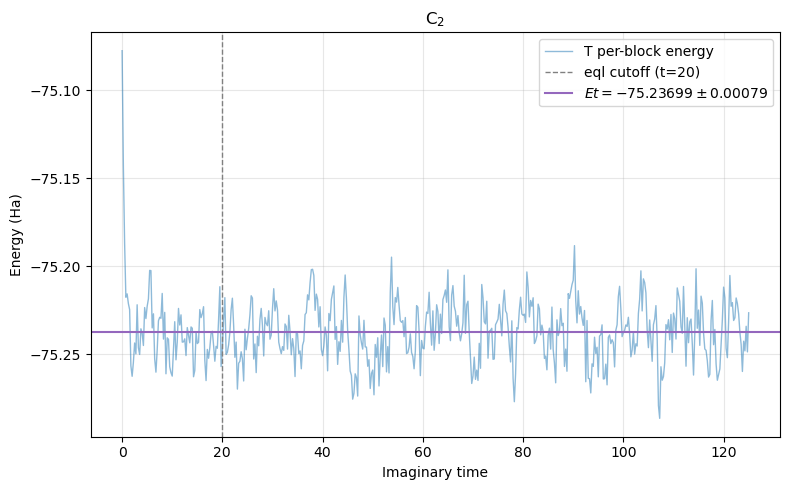

In [51]:
import matplotlib.pyplot as plt

imag_time = np.arange(0, nsamples + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
wt11 = wps_sp11[mask]
et11 = ent_sp11[mask]
N = len(wt11)

Et11_mean = (np.sum(wt11 * et11) / np.sum(wt11)).real

wt11var = np.sum(wt11 * (et11 - Et11_mean) ** 2) / np.sum(wt11) * N / (N - 1)
semt11 = np.sqrt(wt11var / N).real

# print(f"Et = {Et_mean:.6f} +/- {semt:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, ent_sp11.real, lw=1, alpha=0.5, label="T per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(Et11_mean, color="C4", lw=1.5, label=fr"$Et = {Et11_mean:.5f} \pm {semt11:.5f}$")

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("C$_2$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'guide': 'rstoccsd',
            'trial': 'rhf',
            't2_thresh': 1e-3,
            'n_slater': 20,
            }

import time
import numpy as np
# from jax import random
from jax import numpy as jnp

from afqmc import config
from afqmc import prep_exp, sampling_exp

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep_exp.print_start()
config.setup_jax()

prop, wave, ham_data, wave_data, sampler, options = prep_exp.init_afqmc(options=options)

ham_data, wave_data = wave.build_intermediate(ham_data, wave_data)
ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data, init_w, init_e = prep_exp.init_prop_data(wave, wave_data, ham_data, options)
prop_data["cos_g"] = jnp.ones(options["n_walkers"], dtype=jnp.float64)
prop_data["cos_w"] = jnp.ones(options["n_walkers"], dtype=jnp.float64)
# prop_data["weights"] = jnp.ones(options["n_walkers"], dtype=jnp.complex128)
print(init_w, init_e)


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-28-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers     

In [26]:
print("\nEquilibration")
print(f"{'1/T':>5s}  {'weight':>10s}  "
      f"{'energy':>12s}  {'error':>12s}  {'Time':>10s}")
print(f"{0.:5.2f}  {init_w:10.5f}  {init_e:12.5f}  "
      f"{time.time() - init_time:10.2f}")

block_time = prop.dt * sampler.n_prop_steps
nsamples = 500

wps_sp = np.zeros(nsamples, np.complex128)
ent_sp = np.zeros(nsamples, np.complex128)

for n in range(nsamples):
    prop_data, (wp, tsp_mean, tsp_err) \
        = block_sample(sampler, prop, wave, prop_data, ham_data, wave_data)

    wps_sp[n] = wp
    ent_sp[n] = tsp_mean

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * tsp_mean.real
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(nsamples // 10, 1), 20)) == 0 and n > 0:
        print(f"{(n+1)*block_time:5.2f}  "
            #   f"{wt:10.5f}  {gsp_mean:12.5f}  "
              f"{wp:10.5f}  {tsp_mean:12.5f}  "
              f"{prop_data['cos_g'].mean():12.5f}  {prop_data['cos_w'].mean():12.5f}"
              f"{time.time() - init_time:10.2f}")


Equilibration
  1/T      weight        energy         error        Time
 0.00  1.00000+0.00000j  -75.07744+0.00000j        8.96
 5.00  226.57258+2.40918j  -75.29470+0.00234j       0.99466       0.99990     18.91
10.00  226.85717-2.69713j  -75.29264-0.00347j       0.98972       0.99988     25.01
15.00  225.08160+0.72883j  -75.25195+0.00291j       0.96280       0.99975     31.11
20.00  217.02054+4.72888j  -75.32428-0.00185j       0.98773       0.99980     37.20
25.00  226.46617-5.54683j  -75.31876-0.01163j       0.98710       0.99978     43.30
30.00  222.77492+3.85609j  -75.28033+0.01211j       0.97170       0.99891     49.39
35.00  214.62466+5.00872j  -75.32811+0.00407j       0.97324       0.99975     55.49
40.00  210.17193+2.89225j  -75.31827+0.02773j       0.97199       0.99959     61.59
45.00  209.87499-6.72828j  -75.32101-0.01691j       0.98420       0.99985     67.69
50.00  217.10884-2.13533j  -75.32469+0.03122j       0.97657       0.99946     73.78
55.00  215.80515+2.54262j  -75.

In [27]:
wps_sp2 = np.hstack(([300], wps_sp))
ent_sp2 = np.hstack(([mf.e_tot], ent_sp))

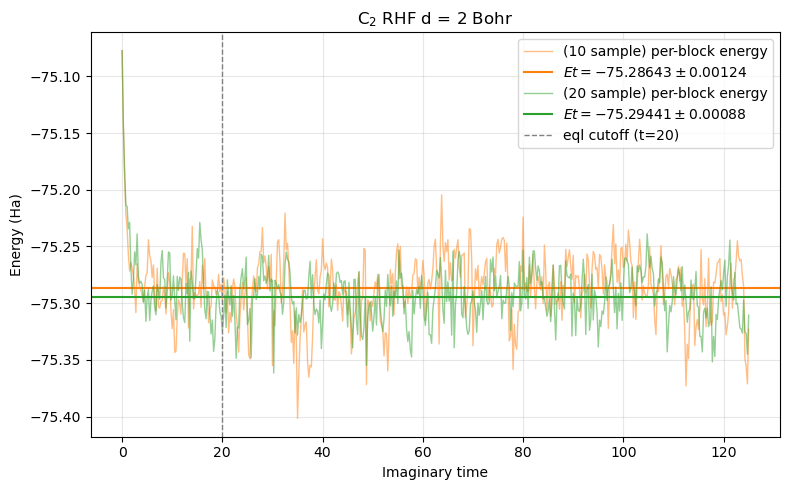

In [29]:
import matplotlib.pyplot as plt

imag_time = np.arange(0, nsamples + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
wt1 = wps_sp1[mask]
et1 = ent_sp1[mask]
wt2 = wps_sp2[mask]
et2 = ent_sp2[mask]
N = len(wt1)

Et1_mean = (np.sum(wt1 * et1) / np.sum(wt1)).real
Et2_mean = (np.sum(wt2 * et2) / np.sum(wt2)).real

wt1var = np.sum(wt1 * (et1 - Et1_mean) ** 2) / np.sum(wt1) * N / (N - 1)
semt1 = np.sqrt(wt1var / N).real
wt2var = np.sum(wt2 * (et2 - Et2_mean) ** 2) / np.sum(wt2) * N / (N - 1)
semt2 = np.sqrt(wt2var / N).real

# --- plot ---
plt.figure(figsize=(8, 5))

plt.plot(imag_time, ent_sp1.real, color="C1", lw=1, alpha=0.5, label="(10 sample) per-block energy")
plt.axhline(Et1_mean, color="C1", lw=1.5, label=fr"$Et = {Et1_mean:.5f} \pm {semt1:.5f}$")
plt.plot(imag_time, ent_sp2.real, color="C2", lw=1, alpha=0.5, label="(20 sample) per-block energy")
plt.axhline(Et2_mean, color="C2", lw=1.5, label=fr"$Et = {Et2_mean:.5f} \pm {semt2:.5f}$")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("C$_2$ RHF d = 2 Bohr")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'guide': 'rstoccsd',
            'trial': 'rhf',
            't2_thresh': 1e-3,
            'n_slater': 30,
            }

import time
import numpy as np
from jax import numpy as jnp

from afqmc import config
from afqmc import prep_exp, sampling_exp

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep_exp.print_start()
config.setup_jax()

prop, wave, ham_data, wave_data, sampler, options = prep_exp.init_afqmc(options=options)

ham_data, wave_data = wave.build_intermediate(ham_data, wave_data)
ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data, init_w, init_e = prep_exp.init_prop_data(wave, wave_data, ham_data, options)
prop_data["cos_g"] = jnp.ones(options["n_walkers"], dtype=jnp.float64)
prop_data["cos_w"] = jnp.ones(options["n_walkers"], dtype=jnp.float64)
print(init_w, init_e)


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-28-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers     

In [31]:
print("\nEquilibration")
print(f"{'1/T':>5s}  {'weight':>10s}  "
      f"{'energy':>12s}  {'error':>12s}  {'Time':>10s}")
print(f"{0.:5.2f}  {init_w:10.5f}  {init_e:12.5f}  "
      f"{time.time() - init_time:10.2f}")

block_time = prop.dt * sampler.n_prop_steps
nsamples = 500

wps_sp = np.zeros(nsamples, np.complex128)
ent_sp = np.zeros(nsamples, np.complex128)

for n in range(nsamples):
    prop_data, (wp, tsp_mean, tsp_err) \
        = block_sample(sampler, prop, wave, prop_data, ham_data, wave_data)

    wps_sp[n] = wp
    ent_sp[n] = tsp_mean

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * tsp_mean.real
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(nsamples // 10, 1), 20)) == 0 and n > 0:
        print(f"{(n+1)*block_time:5.2f}  "
            #   f"{wt:10.5f}  {gsp_mean:12.5f}  "
              f"{wp:10.5f}  {tsp_mean:12.5f}  "
              f"{prop_data['cos_g'].mean():12.5f}  {prop_data['cos_w'].mean():12.5f}"
              f"{time.time() - init_time:10.2f}")


Equilibration
  1/T      weight        energy         error        Time
 0.00  1.00000+0.00000j  -75.07744+0.00000j       10.56
 5.00  218.24120-1.01911j  -75.29229-0.00682j       0.99383       0.99989     23.48
10.00  228.00281+0.22239j  -75.28051-0.00986j       0.98838       0.99976     32.47
15.00  238.15425-7.39189j  -75.27705-0.02065j       0.97794       0.99959     41.46
20.00  216.22481-3.90579j  -75.32187-0.00491j       0.98602       0.99976     50.45
25.00  229.99315+0.71305j  -75.29535+0.00053j       0.99434       0.99989     59.47
30.00  225.51991-3.95685j  -75.28146-0.00963j       0.98249       0.99979     68.52
35.00  222.87164+2.80605j  -75.29260-0.00042j       0.98924       0.99980     77.57
40.00  223.93368+1.18866j  -75.29008+0.00553j       0.99517       0.99985     86.63
45.00  214.65646-0.62203j  -75.30160+0.00656j       0.97239       0.99970     95.69
50.00  218.12860+0.46602j  -75.30411+0.00085j       0.97926       0.99982    104.75
55.00  225.30785+2.30257j  -75.

In [32]:
wps_sp3 = np.hstack(([300], wps_sp))
ent_sp3 = np.hstack(([mf.e_tot], ent_sp))

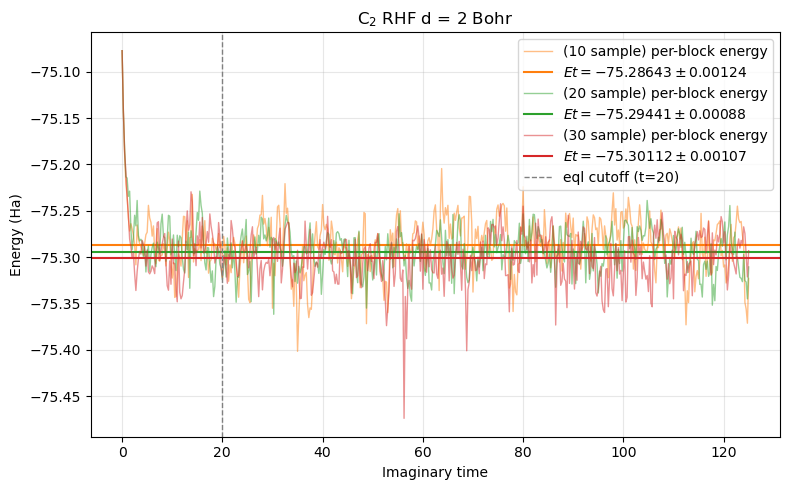

In [33]:

imag_time = np.arange(0, nsamples + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
wt1 = wps_sp1[mask]
et1 = ent_sp1[mask]
wt2 = wps_sp2[mask]
et2 = ent_sp2[mask]
wt3 = wps_sp3[mask]
et3 = ent_sp3[mask]
N = len(wt1)

Et1_mean = (np.sum(wt1 * et1) / np.sum(wt1)).real
Et2_mean = (np.sum(wt2 * et2) / np.sum(wt2)).real
Et3_mean = (np.sum(wt3 * et3) / np.sum(wt3)).real

wt1var = np.sum(wt1 * (et1 - Et1_mean) ** 2) / np.sum(wt1) * N / (N - 1)
semt1 = np.sqrt(wt1var / N).real
wt2var = np.sum(wt2 * (et2 - Et2_mean) ** 2) / np.sum(wt2) * N / (N - 1)
semt2 = np.sqrt(wt2var / N).real
wt3var = np.sum(wt3 * (et3 - Et3_mean) ** 2) / np.sum(wt3) * N / (N - 1)
semt3 = np.sqrt(wt3var / N).real

# --- plot ---
plt.figure(figsize=(8, 5))

plt.plot(imag_time, ent_sp1.real, color="C1", lw=1, alpha=0.5, label="(10 sample) per-block energy")
plt.axhline(Et1_mean, color="C1", lw=1.5, label=fr"$Et = {Et1_mean:.5f} \pm {semt1:.5f}$")
plt.plot(imag_time, ent_sp2.real, color="C2", lw=1, alpha=0.5, label="(20 sample) per-block energy")
plt.axhline(Et2_mean, color="C2", lw=1.5, label=fr"$Et = {Et2_mean:.5f} \pm {semt2:.5f}$")
plt.plot(imag_time, ent_sp3.real, color="C3", lw=1, alpha=0.5, label="(30 sample) per-block energy")
plt.axhline(Et3_mean, color="C3", lw=1.5, label=fr"$Et = {Et3_mean:.5f} \pm {semt3:.5f}$")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("C$_2$ RHF d = 2 Bohr")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'guide': 'rstoccsd',
            'trial': 'rhf',
            't2_thresh': 1e-3,
            'n_slater': 50,
            }

import time
import numpy as np
from jax import numpy as jnp

from afqmc import config
from afqmc import prep_exp, sampling_exp

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep_exp.print_start()
config.setup_jax()

prop, wave, ham_data, wave_data, sampler, options = prep_exp.init_afqmc(options=options)

ham_data, wave_data = wave.build_intermediate(ham_data, wave_data)
ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data, init_w, init_e = prep_exp.init_prop_data(wave, wave_data, ham_data, options)
prop_data["cos_g"] = jnp.ones(options["n_walkers"], dtype=jnp.float64)
prop_data["cos_w"] = jnp.ones(options["n_walkers"], dtype=jnp.float64)
print(init_w, init_e)


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-28-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers     

In [36]:
print(prop.n_slater)

print("\nEquilibration")

print(f"{'1/T':>5s}  {'weight':>10s}  "
      f"{'energy':>12s}  {'error':>12s}  {'Time':>10s}")
print(f"{0.:5.2f}  {init_w:10.5f}  {init_e:12.5f}  "
      f"{time.time() - init_time:10.2f}")

block_time = prop.dt * sampler.n_prop_steps
nsamples = 500

wps_sp = np.zeros(nsamples, np.complex128)
ent_sp = np.zeros(nsamples, np.complex128)

for n in range(nsamples):
    prop_data, (wp, tsp_mean, tsp_err) \
        = block_sample(sampler, prop, wave, prop_data, ham_data, wave_data)

    wps_sp[n] = wp
    ent_sp[n] = tsp_mean

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * tsp_mean.real
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(nsamples // 10, 1), 20)) == 0 and n > 0:
        print(f"{(n+1)*block_time:5.2f}  "
            #   f"{wt:10.5f}  {gsp_mean:12.5f}  "
              f"{wp:10.5f}  {tsp_mean:12.5f}  "
              f"{prop_data['cos_g'].mean():12.5f}  {prop_data['cos_w'].mean():12.5f}"
              f"{time.time() - init_time:10.2f}")

50

Equilibration
  1/T      weight        energy         error        Time
 0.00  1.00000+0.00000j  -75.07744+0.00000j       46.12
 5.00  224.54033+1.59018j  -75.29046+0.00365j       0.99696       0.99990     64.81
10.00  231.36796-2.86824j  -75.28441-0.00703j       0.98165       0.99751     79.73
15.00  223.79517-8.85077j  -75.27455-0.02022j       0.99403       0.99989     94.65
20.00  226.60222-5.89004j  -75.28254-0.01632j       0.99262       0.99982    109.56
25.00  218.76881+1.86491j  -75.31505+0.01035j       0.99436       0.99981    124.47
30.00  218.40150-3.71952j  -75.32587-0.00331j       0.99383       0.99985    139.38
35.00  210.36617+0.67827j  -75.34885+0.00400j       0.99315       0.99984    154.30
40.00  215.86343+5.28329j  -75.30257+0.01752j       0.99576       0.99984    169.21
45.00  221.66903-1.81873j  -75.26775-0.00559j       0.98692       0.99964    184.13
50.00  222.39561+10.67140j  -75.26881+0.02606j       0.97769       0.99982    199.06
55.00  219.19052+6.38010j  

In [37]:
wps_sp4 = np.hstack(([300], wps_sp))
ent_sp4 = np.hstack(([mf.e_tot], ent_sp))

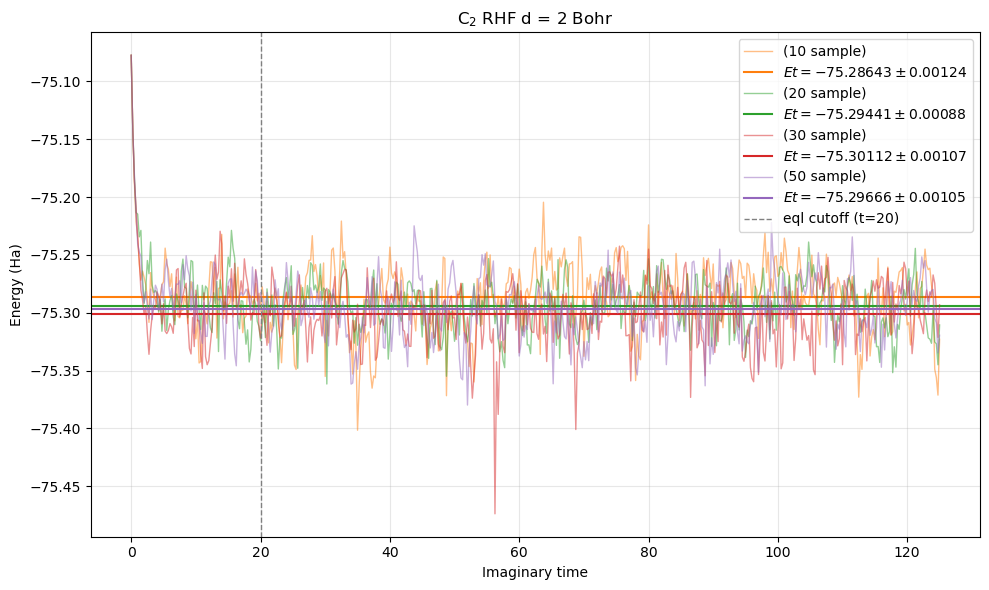

In [39]:

imag_time = np.arange(0, nsamples + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0

wt4 = wps_sp4[mask]
et4 = ent_sp4[mask]
N = len(wt1)

Et4_mean = (np.sum(wt4 * et4) / np.sum(wt4)).real

wt4var = np.sum(wt4 * (et4 - Et4_mean) ** 2) / np.sum(wt4) * N / (N - 1)
semt4 = np.sqrt(wt4var / N).real

# --- plot ---
plt.figure(figsize=(10, 6))

plt.plot(imag_time, ent_sp1.real, color="C1", lw=1, alpha=0.5, label="(10 sample)")
plt.axhline(Et1_mean, color="C1", lw=1.5, label=fr"$Et = {Et1_mean:.5f} \pm {semt1:.5f}$")
plt.plot(imag_time, ent_sp2.real, color="C2", lw=1, alpha=0.5, label="(20 sample) ")
plt.axhline(Et2_mean, color="C2", lw=1.5, label=fr"$Et = {Et2_mean:.5f} \pm {semt2:.5f}$")
plt.plot(imag_time, ent_sp3.real, color="C3", lw=1, alpha=0.5, label="(30 sample) ")
plt.axhline(Et3_mean, color="C3", lw=1.5, label=fr"$Et = {Et3_mean:.5f} \pm {semt3:.5f}$")
plt.plot(imag_time, ent_sp4.real, color="C4", lw=1, alpha=0.5, label="(50 sample) ")
plt.axhline(Et4_mean, color="C4", lw=1.5, label=fr"$Et = {Et4_mean:.5f} \pm {semt4:.5f}$")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("C$_2$ RHF d = 2 Bohr")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'guide': 'rstoccsd',
            'trial': 'rhf',
            't2_thresh': 1e-3,
            'n_slater': 5,
            }

import time
import numpy as np
from jax import numpy as jnp

from afqmc import config
from afqmc import prep_exp, sampling_exp

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep_exp.print_start()
config.setup_jax()

prop, wave, ham_data, wave_data, sampler, options = prep_exp.init_afqmc(options=options)

ham_data, wave_data = wave.build_intermediate(ham_data, wave_data)
ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data, init_w, init_e = prep_exp.init_prop_data(wave, wave_data, ham_data, options)
prop_data["cos_g"] = jnp.ones(options["n_walkers"], dtype=jnp.float64)
prop_data["cos_w"] = jnp.ones(options["n_walkers"], dtype=jnp.float64)
print(init_w, init_e)


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-28-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers     

In [56]:
print(prop.n_slater)

print("\nEquilibration")

print(f"{'1/T':>5s}  {'weight':>10s}  "
      f"{'energy':>12s}  {'error':>12s}  {'Time':>10s}")
print(f"{0.:5.2f}  {init_w:10.5f}  {init_e:12.5f}  "
      f"{time.time() - init_time:10.2f}")

block_time = prop.dt * sampler.n_prop_steps
nsamples = 500

wps_sp = np.zeros(nsamples, np.complex128)
ent_sp = np.zeros(nsamples, np.complex128)

for n in range(nsamples):
    prop_data, (wp, tsp_mean, tsp_err) \
        = block_sample(sampler, prop, wave, prop_data, ham_data, wave_data)

    wps_sp[n] = wp
    ent_sp[n] = tsp_mean

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * tsp_mean.real
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(nsamples // 10, 1), 20)) == 0 and n > 0:
        print(f"{(n+1)*block_time:5.2f}  "
            #   f"{wt:10.5f}  {gsp_mean:12.5f}  "
              f"{wp:10.5f}  {tsp_mean:12.5f}  "
              f"{prop_data['cos_g'].mean():12.5f}  {prop_data['cos_w'].mean():12.5f}"
              f"{time.time() - init_time:10.2f}")

5

Equilibration
  1/T      weight        energy         error        Time
 0.00  1.00000+0.00000j  -75.07744+0.00000j        2.51
 5.00  222.23496+6.38475j  -75.25400+0.00157j       0.98910       0.99903      7.71
10.00  239.01775-3.44709j  -75.29145-0.02525j       0.98470       0.99978      9.45
15.00  234.95524+7.51534j  -75.23429-0.01475j       0.91019       0.99903     11.19
20.00  217.14165+3.48626j  -75.27207-0.00937j       0.96251       0.99965     12.93
25.00  232.92149-1.63484j  -75.25393-0.00352j       0.96799       0.99944     14.67
30.00  226.85888-2.49061j  -75.27717-0.00831j       0.98831       0.99970     16.41
35.00  239.37283-13.82820j  -75.24765-0.00379j       0.97787       0.99841     18.15
40.00  241.44747-5.21951j  -75.25143-0.00342j       0.97689       0.99984     19.90
45.00  223.21459-2.51437j  -75.28467+0.00141j       0.99084       0.99983     21.64
50.00  218.81369-3.63235j  -75.26062+0.00307j       0.96124       0.99952     23.38
55.00  240.09331+2.57124j  -

In [57]:
wps_sp0 = np.hstack(([300], wps_sp))
ent_sp0 = np.hstack(([mf.e_tot], ent_sp))

imag_time = np.arange(0, nsamples + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0

wt0 = wps_sp0[mask]
et0 = ent_sp0[mask]
N = len(wt0)

Et0_mean = (np.sum(wt0 * et0) / np.sum(wt0)).real
wt0var = np.sum(wt0 * (et0 - Et0_mean) ** 2) / np.sum(wt0) * N / (N - 1)
semt0 = np.sqrt(wt0var / N).real


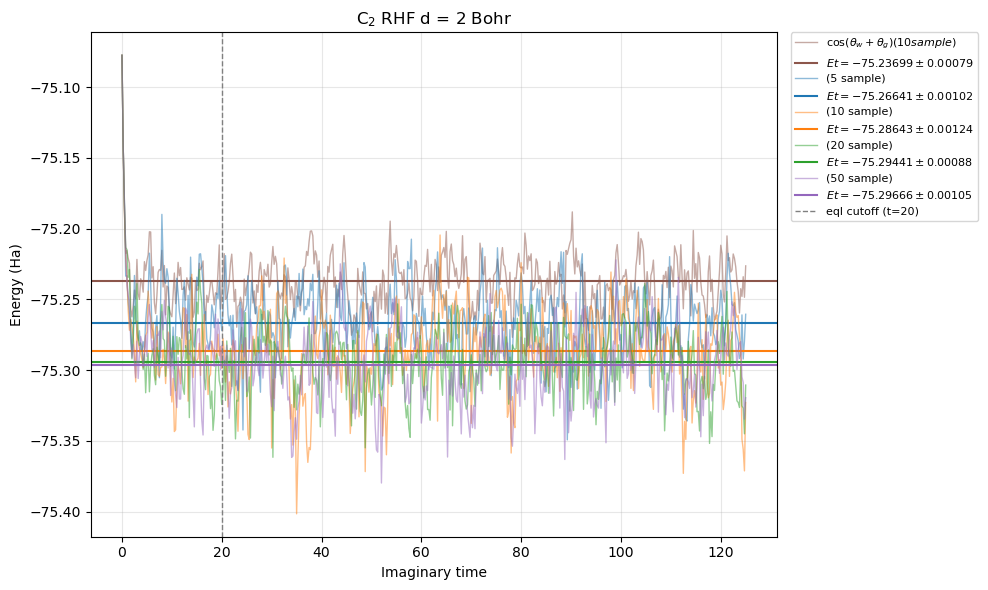

In [61]:
# --- plot ---
plt.figure(figsize=(10, 6))

plt.plot(imag_time, ent_sp11.real, color="C5", lw=1, alpha=0.5, label=r"$\cos(\theta_w + \theta_g) (10 sample)$")
plt.axhline(Et11_mean, color="C5", lw=1.5, label=fr"$Et = {Et11_mean:.5f} \pm {semt11:.5f}$")

plt.plot(imag_time, ent_sp0.real, color="C0", lw=1, alpha=0.5, label="(5 sample)")
plt.axhline(Et0_mean, color="C0", lw=1.5, label=fr"$Et = {Et0_mean:.5f} \pm {semt0:.5f}$")
plt.plot(imag_time, ent_sp1.real, color="C1", lw=1, alpha=0.5, label="(10 sample)")
plt.axhline(Et1_mean, color="C1", lw=1.5, label=fr"$Et = {Et1_mean:.5f} \pm {semt1:.5f}$")
plt.plot(imag_time, ent_sp2.real, color="C2", lw=1, alpha=0.5, label="(20 sample)")
plt.axhline(Et2_mean, color="C2", lw=1.5, label=fr"$Et = {Et2_mean:.5f} \pm {semt2:.5f}$")
# plt.plot(imag_time, ent_sp3.real, color="C3", lw=1, alpha=0.5, label="(30 sample)")
# plt.axhline(Et3_mean, color="C3", lw=1.5, label=fr"$Et = {Et3_mean:.5f} \pm {semt3:.5f}$")
plt.plot(imag_time, ent_sp4.real, color="C4", lw=1, alpha=0.5, label="(50 sample)")
plt.axhline(Et4_mean, color="C4", lw=1.5, label=fr"$Et = {Et4_mean:.5f} \pm {semt4:.5f}$")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("C$_2$ RHF d = 2 Bohr")
plt.grid(alpha=0.3)

# legend outside, on the right
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=8)
plt.tight_layout()
plt.show()

In [65]:
options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'guide': 'rcisd',
            'trial': 'rhf',
            't2_thresh': 1e-3,
            'n_slater': 50,
            }

import time
import numpy as np
from jax import numpy as jnp

from afqmc import config
from afqmc import prep_exp, sampling_exp

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep_exp.print_start()
config.setup_jax()

prop, wave, ham_data, wave_data, sampler, options = prep_exp.init_afqmc(options=options)

ham_data, wave_data = wave.build_intermediate(ham_data, wave_data)
ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data, init_w, init_e = prep_exp.init_prop_data(wave, wave_data, ham_data, options)
prop_data["cos_g"] = jnp.ones(options["n_walkers"], dtype=jnp.float64)
prop_data["cos_w"] = jnp.ones(options["n_walkers"], dtype=jnp.float64)
print(init_w, init_e)


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-28-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers     

In [66]:
# print(prop.n_slater)

print("\nEquilibration")

print(f"{'1/T':>5s}  {'weight':>10s}  "
      f"{'energy':>12s}  {'error':>12s}  {'Time':>10s}")
print(f"{0.:5.2f}  {init_w:10.5f}  {init_e:12.5f}  "
      f"{time.time() - init_time:10.2f}")

block_time = prop.dt * sampler.n_prop_steps
nsamples = 500

wps_sp = np.zeros(nsamples, np.complex128)
ent_sp = np.zeros(nsamples, np.complex128)

for n in range(nsamples):
    prop_data, (wp, tsp_mean, tsp_err) \
        = sampler.block_sample(prop, wave, prop_data, ham_data, wave_data)

    wps_sp[n] = wp
    ent_sp[n] = tsp_mean

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * tsp_mean.real
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(nsamples // 10, 1), 20)) == 0 and n > 0:
        print(f"{(n+1)*block_time:5.2f}  "
            #   f"{wt:10.5f}  {gsp_mean:12.5f}  "
              f"{wp:10.5f}  {tsp_mean:12.5f}  "
            #   f"{prop_data['cos_g'].mean():12.5f}  {prop_data['cos_w'].mean():12.5f}"
              f"{time.time() - init_time:10.2f}")


Equilibration
  1/T      weight        energy         error        Time
 0.00  1.00000+0.00000j  -75.07744+0.00000j        8.89
 5.00  227.08168-3.04572j  -75.30146-0.01483j       13.47
10.00  227.30392-3.11723j  -75.29651-0.01299j       14.10
15.00  226.21414+1.11623j  -75.29304+0.00492j       14.73
20.00  231.66381+4.33233j  -75.28689+0.01206j       15.36
25.00  228.05988+1.37764j  -75.29875-0.00194j       15.98
30.00  225.45521+3.14198j  -75.31594+0.00120j       16.61
35.00  228.19519-1.09786j  -75.28227-0.02003j       17.24
40.00  232.37039+6.90735j  -75.25792+0.01242j       17.87
45.00  218.39736-2.54471j  -75.32984-0.00917j       18.49
50.00  226.36497+2.56637j  -75.31173+0.01275j       19.12
55.00  226.53502+2.47188j  -75.28094+0.01580j       19.75
60.00  225.64596-1.38568j  -75.28811+0.00743j       20.38
65.00  218.32889-1.93792j  -75.32247+0.00479j       21.01
70.00  227.80916+3.56120j  -75.27968-0.00063j       21.64
75.00  224.50002-3.38258j  -75.32263-0.03235j       22.26
8

In [67]:
wps_sp6 = np.hstack(([300], wps_sp))
ent_sp6 = np.hstack(([mf.e_tot], ent_sp))

imag_time = np.arange(0, nsamples + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0

wt6 = wps_sp6[mask]
et6 = ent_sp6[mask]
N = len(wt6)

Et6_mean = (np.sum(wt6 * et6) / np.sum(wt6)).real
wt6var = np.sum(wt6 * (et6 - Et6_mean) ** 2) / np.sum(wt6) * N / (N - 1)
semt6 = np.sqrt(wt6var / N).real

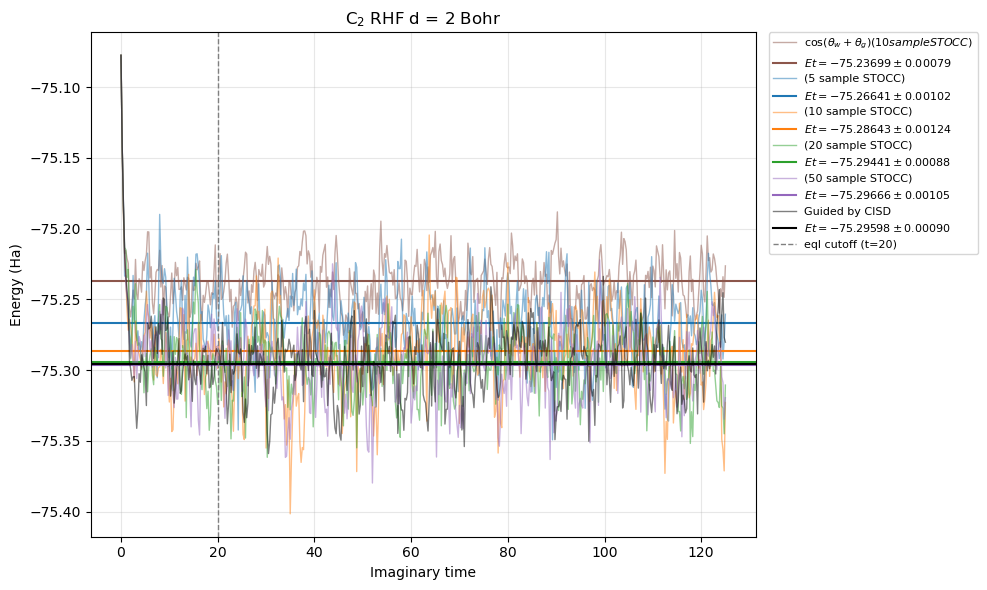

In [77]:
# --- plot ---
plt.figure(figsize=(10, 6))

plt.plot(imag_time, ent_sp11.real, color="C5", lw=1, alpha=0.5, label=r"$\cos(\theta_w + \theta_g) (10 sample STOCC)$")
plt.axhline(Et11_mean, color="C5", lw=1.5, label=fr"$Et = {Et11_mean:.5f} \pm {semt11:.5f}$")

plt.plot(imag_time, ent_sp0.real, color="C0", lw=1, alpha=0.5, label="(5 sample STOCC)")
plt.axhline(Et0_mean, color="C0", lw=1.5, label=fr"$Et = {Et0_mean:.5f} \pm {semt0:.5f}$")
plt.plot(imag_time, ent_sp1.real, color="C1", lw=1, alpha=0.5, label="(10 sample STOCC)")
plt.axhline(Et1_mean, color="C1", lw=1.5, label=fr"$Et = {Et1_mean:.5f} \pm {semt1:.5f}$")
plt.plot(imag_time, ent_sp2.real, color="C2", lw=1, alpha=0.5, label="(20 sample STOCC)")
plt.axhline(Et2_mean, color="C2", lw=1.5, label=fr"$Et = {Et2_mean:.5f} \pm {semt2:.5f}$")
# plt.plot(imag_time, ent_sp3.real, color="C3", lw=1, alpha=0.5, label="(30 sample)")
# plt.axhline(Et3_mean, color="C3", lw=1.5, label=fr"$Et = {Et3_mean:.5f} \pm {semt3:.5f}$")
plt.plot(imag_time, ent_sp4.real, color="C4", lw=1, alpha=0.5, label="(50 sample STOCC)")
plt.axhline(Et4_mean, color="C4", lw=1.5, label=fr"$Et = {Et4_mean:.5f} \pm {semt4:.5f}$")
plt.plot(imag_time, ent_sp6.real, color="k", lw=1, alpha=0.5, label="Guided by CISD")
plt.axhline(Et6_mean, color="k", lw=1.5, label=fr"$Et = {Et6_mean:.5f} \pm {semt6:.5f}$")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("C$_2$ RHF d = 2 Bohr")
plt.grid(alpha=0.3)

# legend outside, on the right
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=8)
plt.tight_layout()
plt.show()

In [78]:
options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'guide': 'rhf',
            'trial': 'rhf',
            't2_thresh': 1e-3,
            'n_slater': 50,
            }

import time
import numpy as np
from jax import numpy as jnp

from afqmc import config
from afqmc import prep_exp, sampling_exp

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep_exp.print_start()
config.setup_jax()

prop, wave, ham_data, wave_data, sampler, options = prep_exp.init_afqmc(options=options)

ham_data, wave_data = wave.build_intermediate(ham_data, wave_data)
ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data, init_w, init_e = prep_exp.init_prop_data(wave, wave_data, ham_data, options)
prop_data["cos_g"] = jnp.ones(options["n_walkers"], dtype=jnp.float64)
prop_data["cos_w"] = jnp.ones(options["n_walkers"], dtype=jnp.float64)
print(init_w, init_e)


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-28-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers     

In [79]:
print("\nEquilibration")

print(f"{'1/T':>5s}  {'weight':>10s}  "
      f"{'energy':>12s}  {'error':>12s}  {'Time':>10s}")
print(f"{0.:5.2f}  {init_w:10.5f}  {init_e:12.5f}  "
      f"{time.time() - init_time:10.2f}")

block_time = prop.dt * sampler.n_prop_steps
nsamples = 500

wps_sp = np.zeros(nsamples, np.complex128)
ent_sp = np.zeros(nsamples, np.complex128)

for n in range(nsamples):
    prop_data, (wp, tsp_mean, tsp_err) \
        = sampler.block_sample(prop, wave, prop_data, ham_data, wave_data)

    wps_sp[n] = wp
    ent_sp[n] = tsp_mean

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * tsp_mean.real
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(nsamples // 10, 1), 20)) == 0 and n > 0:
        print(f"{(n+1)*block_time:5.2f}  "
            #   f"{wt:10.5f}  {gsp_mean:12.5f}  "
              f"{wp:10.5f}  {tsp_mean:12.5f}  "
            #   f"{prop_data['cos_g'].mean():12.5f}  {prop_data['cos_w'].mean():12.5f}"
              f"{time.time() - init_time:10.2f}")


Equilibration
  1/T      weight        energy         error        Time
 0.00  1.00000+0.00000j  -75.07744+0.00000j       14.51
 5.00  300.35593-0.00000j  -75.31346+0.00999j       17.92
10.00  299.72354-0.00000j  -75.25709+0.00071j       18.30
15.00  299.43710-0.00000j  -75.30146-0.00232j       18.68
20.00  298.55038+0.00000j  -75.28694-0.00206j       19.06
25.00  298.97244+0.00000j  -75.28961-0.00249j       19.44
30.00  299.85678+0.00000j  -75.28422-0.01484j       19.83
35.00  299.61908+0.00000j  -75.29646+0.00154j       20.21
40.00  299.03402-0.00000j  -75.30478+0.01231j       20.59
45.00  299.66867-0.00000j  -75.30646-0.00340j       20.97
50.00  298.64851-0.00000j  -75.28352+0.01701j       21.36
55.00  299.64988-0.00000j  -75.31646+0.00395j       21.74
60.00  300.42709+0.00000j  -75.40176-0.01146j       22.13
65.00  298.91460+0.00000j  -75.22278-0.00608j       22.51
70.00  299.13348-0.00000j  -75.28594+0.00736j       22.89
75.00  299.04165+0.00000j  -75.25061+0.00346j       23.27
8

In [80]:
wps_sp5 = np.hstack(([300], wps_sp))
ent_sp5 = np.hstack(([mf.e_tot], ent_sp))

imag_time = np.arange(0, nsamples + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0

wt5 = wps_sp5[mask]
et5 = ent_sp5[mask]
N = len(wt5)

Et5_mean = (np.sum(wt5 * et5) / np.sum(wt5)).real
wt5var = np.sum(wt5 * (et5 - Et5_mean) ** 2) / np.sum(wt5) * N / (N - 1)
semt5 = np.sqrt(wt5var / N).real

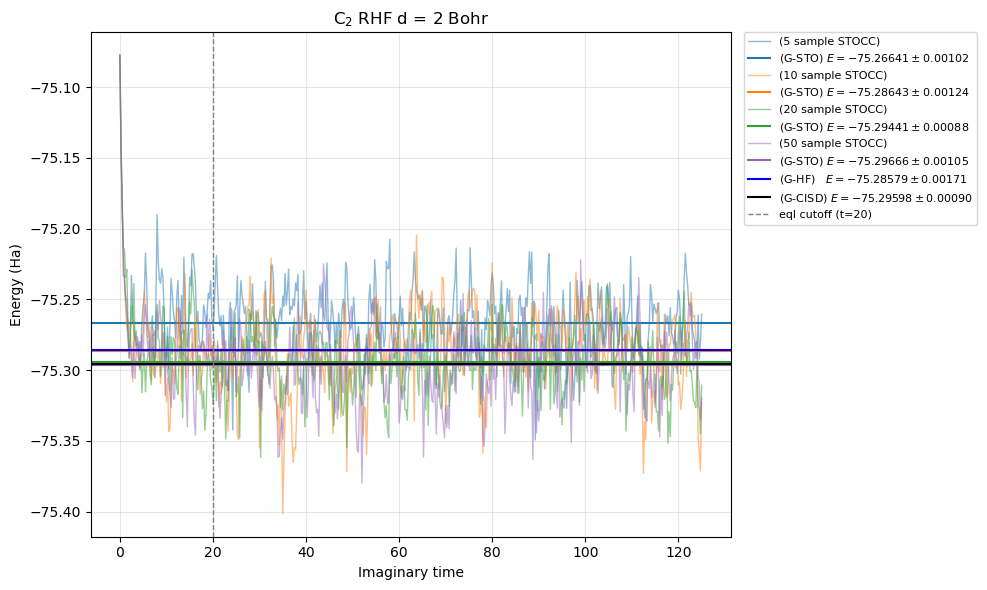

In [91]:
plt.figure(figsize=(10, 6))

# plt.plot(imag_time, ent_sp11.real, color="C5", lw=1, alpha=0.5, label=r"$\cos(\theta_w + \theta_g) (10 sample STOCC)$")
# plt.axhline(Et11_mean, color="C5", lw=1.5, label=fr"$Et = {Et11_mean:.5f} \pm {semt11:.5f}$")

plt.plot(imag_time, ent_sp0.real, color="C0", lw=1, alpha=0.5, label="(5 sample STOCC)")
plt.axhline(Et0_mean, color="C0", lw=1.5, label=fr"(G-STO) $E = {Et0_mean:.5f} \pm {semt0:.5f}$")
plt.plot(imag_time, ent_sp1.real, color="C1", lw=1, alpha=0.5, label="(10 sample STOCC)")
plt.axhline(Et1_mean, color="C1", lw=1.5, label=fr"(G-STO) $E = {Et1_mean:.5f} \pm {semt1:.5f}$")
plt.plot(imag_time, ent_sp2.real, color="C2", lw=1, alpha=0.5, label="(20 sample STOCC)")
plt.axhline(Et2_mean, color="C2", lw=1.5, label=fr"(G-STO) $E = {Et2_mean:.5f} \pm {semt2:.5f}$")
# plt.plot(imag_time, ent_sp3.real, color="C3", lw=1, alpha=0.5, label="(30 sample)")
# plt.axhline(Et3_mean, color="C3", lw=1.5, label=fr"$Et = {Et3_mean:.5f} \pm {semt3:.5f}$")
plt.plot(imag_time, ent_sp4.real, color="C4", lw=1, alpha=0.5, label="(50 sample STOCC)")
plt.axhline(Et4_mean, color="C4", lw=1.5, label=fr"(G-STO) $E = {Et4_mean:.5f} \pm {semt4:.5f}$")

# plt.plot(imag_time, ent_sp5.real, color="b", lw=1, alpha=0.5, label="Guided by HF")
plt.axhline(Et5_mean, color="b", lw=1.5, label=fr"(G-HF)   $E = {Et5_mean:.5f} \pm {semt5:.5f}$")
# plt.plot(imag_time, ent_sp6.real, color="k", lw=1, alpha=0.5, label="Guided by CISD")
plt.axhline(Et6_mean, color="k", lw=1.5, label=fr"(G-CISD) $E = {Et6_mean:.5f} \pm {semt6:.5f}$")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("C$_2$ RHF d = 2 Bohr")
plt.grid(alpha=0.3)

# legend outside, on the right
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=8)
plt.tight_layout()
plt.show()

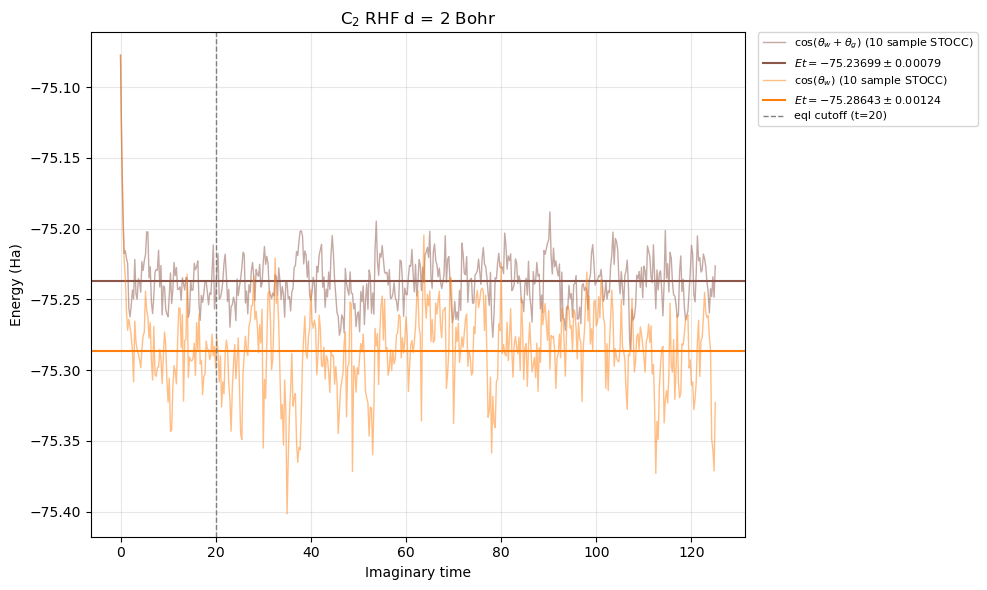

In [87]:
plt.figure(figsize=(10, 6))

plt.plot(imag_time, ent_sp11.real, color="C5", lw=1, alpha=0.5, label=fr"$\cos(\theta_w + \theta_g)$ (10 sample STOCC)")
plt.axhline(Et11_mean, color="C5", lw=1.5, label=fr"$Et = {Et11_mean:.5f} \pm {semt11:.5f}$")

plt.plot(imag_time, ent_sp1.real, color="C1", lw=1, alpha=0.5, label=fr"$\cos(\theta_w)$ (10 sample STOCC)")
plt.axhline(Et1_mean, color="C1", lw=1.5, label=fr"$Et = {Et1_mean:.5f} \pm {semt1:.5f}$")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("C$_2$ RHF d = 2 Bohr")
plt.grid(alpha=0.3)

# legend outside, on the right
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=8)
plt.tight_layout()
plt.show()